# Figure 3 notebook - this focuses on severe

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# setup all the imports
import matplotlib.font_manager
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  # noqa: E402
import numpy as np
import seaborn as sns
import pandas as pd

flist = matplotlib.font_manager.get_font_names()
from pathlib import Path  # noqa: E402

import extremeweatherbench as ewb

# make the basepath - change this to your local path
basepath = Path.home() / "extreme-weather-bench-paper" / ""
basepath = str(basepath) + "/"

# ugly hack to load in our plotting scripts
# import sys  # noqa: E402

#sys.path.append(basepath + "/docs/notebooks/")
import src.plots.plotting_utils as plot_utils  # noqa: E402
import src.plots.results_utils as results_utils  # noqa: E402
import src.plots.severe_convection_utils as severe_utils
import src.plots.plotting_styles as ps
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


In [3]:
# load in all of the events in the yaml file
print("loading in the events yaml file")
ewb_cases = ewb.cases.load_ewb_events_yaml_into_case_list()

# downselect to only the severe cases
ewb_cases = [n for n in ewb_cases if n.event_type == "severe_convection"]

# build out all of the expected data to evalate the case (we need this so we can plot
# the LSR reports)
case_operators = ewb.cases.build_case_operators(
    ewb_cases, ewb.defaults.get_brightband_evaluation_objects()
)

# load the marginal severe cases
marginal_severe_yaml_path = Path(ewb.__file__).parent / "data" / "marginal_severe_convection_cases.yaml"
marginal_severe_cases = ewb.cases.load_individual_cases_from_yaml(marginal_severe_yaml_path)
marginal_severe_cases = [n for n in marginal_severe_cases if n.event_type == "severe_convection"]
marginal_severe_case_operators = ewb.cases.build_case_operators(
    marginal_severe_cases, ewb.defaults.get_brightband_evaluation_objects()
)


loading in the events yaml file


In [4]:
# to plot the targets, we need to run the pipeline for each case and target
from joblib import Parallel, delayed  # noqa: E402
from joblib.externals.loky import get_reusable_executor  # noqa: E402

# load in all the case info (note this takes awhile in non-parallel form as it has to
# run all the target information for each case)
# this will return a list of tuples with the case id and the target dataset

print("running the pipeline for each case and target")
parallel = Parallel(n_jobs=32, return_as="generator", backend="loky")
case_operators_with_targets_established_generator = parallel(
    delayed(
        lambda co: (
            co.case_metadata.case_id_number,
            ewb.evaluate.run_pipeline(co.case_metadata, co.target),
        )
    )(case_operator)
    for case_operator in case_operators
)
case_operators_with_targets_established = list(
    case_operators_with_targets_established_generator
)
# this will throw a bunch of errors below but they're not consequential. this releases
# the memory as it shuts down the workers
get_reusable_executor().shutdown(wait=True)

print("running the pipeline for marginal severe cases and target")
parallel = Parallel(n_jobs=32, return_as="generator", backend="loky")
marginal_severe_case_operators_with_targets_established_generator = parallel(
    delayed(
        lambda co: (
            co.case_metadata.case_id_number,
            ewb.evaluate.run_pipeline(co.case_metadata, co.target),
        )
    )(case_operator)
    for case_operator in marginal_severe_case_operators
)
marginal_severe_case_operators_with_targets_established = list(
    marginal_severe_case_operators_with_targets_established_generator
)
# this will throw a bunch of errors below but they're not consequential. this releases
# the memory as it shuts down the workers
get_reusable_executor().shutdown(wait=True)


running the pipeline for each case and target


running the pipeline for marginal severe cases and target


In [5]:
# load the results back in
pang_severe_results = pd.read_pickle(basepath + 'saved_data/bb_pangu_severe_results.pkl')
hres_severe_results = pd.read_pickle(basepath + 'saved_data/hres_severe_results.pkl')
gc_severe_results = pd.read_pickle(basepath + 'saved_data/bb_graphcast_severe_results.pkl')
aifs_severe_results = pd.read_pickle(basepath + 'saved_data/bb_aifs_severe_results.pkl')

# load the non-event severe results
pang_marginal_severe_results = pd.read_pickle(basepath + 'saved_data/bb_pangu_non_event_severe_results.pkl')
hres_marginal_severe_results = pd.read_pickle(basepath + 'saved_data/hres_non_event_severe_results.pkl')
gc_marginal_severe_results = pd.read_pickle(basepath + 'saved_data/bb_graphcast_non_event_severe_results.pkl')
aifs_marginal_severe_results = pd.read_pickle(basepath + 'saved_data/bb_aifs_non_event_severe_results.pkl')

lead_time_days = [1, 3, 5, 7, 10]

In [6]:
gc_gfs_era5_settings_tp  = ps.bb_graphcast_settings | ps.graphcast_style | ps.severe_tp_settings 
pangu_gfs_era5_settings_tp = ps.bb_pangu_settings | ps.pangu_style | ps.severe_tp_settings 
hres_era5_settings_tp = ps.hres_settings | ps.hres_style | ps.severe_tp_settings 
aifs_era5_settings_tp = ps.bb_aifs_settings | ps.aifs_style | ps.severe_tp_settings 

# grab the severe results
gc_severe_plot_tp = results_utils.subset_results_to_xarray(results_df=gc_severe_results, 
    forecast_source=gc_gfs_era5_settings_tp['forecast_source'], 
    target_source='local_storm_reports', metric='TruePositives', lead_time_days=lead_time_days)
pangu_severe_plot_tp  = results_utils.subset_results_to_xarray(results_df=pang_severe_results, 
    forecast_source=pangu_gfs_era5_settings_tp['forecast_source'], 
    target_source='local_storm_reports', metric='TruePositives', lead_time_days=lead_time_days)
hres_severe_plot_tp = results_utils.subset_results_to_xarray(results_df=hres_severe_results, 
    forecast_source=hres_era5_settings_tp['forecast_source'], 
    target_source='local_storm_reports', metric='TruePositives', lead_time_days=lead_time_days)
aifs_severe_plot_tp = results_utils.subset_results_to_xarray(results_df=aifs_severe_results, 
    forecast_source=aifs_era5_settings_tp['forecast_source'], 
    target_source='local_storm_reports', metric='TruePositives', lead_time_days=lead_time_days)

# plot the results
severe_data_tp = [gc_severe_plot_tp, pangu_severe_plot_tp, hres_severe_plot_tp, aifs_severe_plot_tp]
severe_settings_tp = [gc_gfs_era5_settings_tp, pangu_gfs_era5_settings_tp, hres_era5_settings_tp, aifs_era5_settings_tp]


gc_gfs_era5_settings_fn  = ps.bb_graphcast_settings | ps.graphcast_style | ps.severe_fn_settings 
pangu_gfs_era5_settings_fn = ps.bb_pangu_settings | ps.pangu_style | ps.severe_fn_settings 
hres_era5_settings_fn = ps.hres_settings | ps.hres_style | ps.severe_fn_settings 
aifs_era5_settings_fn = ps.bb_aifs_settings | ps.aifs_style | ps.severe_fn_settings 

# grab the results for the false negatives
gc_severe_plot_fn = results_utils.subset_results_to_xarray(results_df=gc_severe_results, 
    forecast_source=gc_gfs_era5_settings_fn['forecast_source'], 
    target_source='local_storm_reports', metric='FalseNegatives', lead_time_days=lead_time_days)
pangu_severe_plot_fn = results_utils.subset_results_to_xarray(results_df=pang_severe_results, 
    forecast_source=pangu_gfs_era5_settings_fn['forecast_source'], 
    target_source='local_storm_reports', metric='FalseNegatives', lead_time_days=lead_time_days)
hres_severe_plot_fn = results_utils.subset_results_to_xarray(results_df=hres_severe_results, 
    forecast_source=hres_era5_settings_fn['forecast_source'], 
    target_source='local_storm_reports', metric='FalseNegatives', lead_time_days=lead_time_days)
aifs_severe_plot_fn = results_utils.subset_results_to_xarray(results_df=aifs_severe_results, 
    forecast_source=aifs_era5_settings_fn['forecast_source'], 
    target_source='local_storm_reports', metric='FalseNegatives', lead_time_days=lead_time_days)

# plot the results
severe_data_fn = [gc_severe_plot_fn, pangu_severe_plot_fn, hres_severe_plot_fn, aifs_severe_plot_fn]
severe_settings_fn = [gc_gfs_era5_settings_fn, pangu_gfs_era5_settings_fn, hres_era5_settings_fn, aifs_era5_settings_fn]

In [7]:
# make the bounding boxes for the regions
# North America
na_bounding_box = [-172, -45, 7, 85]
na_bounding_box_polygon = plot_utils.get_polygon_from_bounding_box(na_bounding_box)
na_bounding_region = ewb.regions.BoundingBoxRegion(latitude_min=7, latitude_max=85, longitude_min=-172, longitude_max=-45)

# australia bounding box
au_bounding_box = [110, 180, -50, -10]
au_bounding_box_polygon = plot_utils.get_polygon_from_bounding_box(au_bounding_box)
au_bounding_region = ewb.regions.BoundingBoxRegion(latitude_min=-50, latitude_max=-10, longitude_min=110, longitude_max=180)

# break the cases into different lists
na_subset = ewb.regions.RegionSubsetter(region=na_bounding_region, method='intersects').subset_case_list(ewb_cases)
au_subset = ewb.regions.RegionSubsetter(region=au_bounding_region, method='intersects').subset_case_list(ewb_cases)

na_case_ids = [n.case_id_number for n in na_subset]
au_case_ids = [n.case_id_number for n in au_subset]

print(f'North America Cases: {na_case_ids}')
print(f'Australia Cases: {au_case_ids}')

# make case ids for the non-event cases
# since all of the non-events are in North America, we can just use the full set of non-event case ids
marginal_case_ids = [n.case_id_number for n in marginal_severe_cases]
na_marginal_case_ids = [n.case_id_number for n in marginal_severe_cases]



North America Cases: [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337]
Australia Cases: [257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279]


In [8]:
def get_error_array_for_heatmap(case_list, results_array, hres_results, forecast_sources, 
    target_source, metric_strs, lead_time_days, higher_is_better_list, case_ids=None):
    """
    This function takes in an array of results and parameters to say which results to grab and returns 
    error arrays and relative arrays for global, north america, and europe.
    """
    # now make the array for the scorecard
    rel_error = {}
    error = {}

    for i, metric in enumerate(metric_strs):
        # initialize the arrays
        rel_error[metric] = np.zeros((len(results_array), len(lead_time_days)))
        error[metric] = np.zeros((len(results_array), len(lead_time_days)))

        higher_is_better = higher_is_better_list[i]

        for j, results_df in enumerate(results_array):
            my_mean, my_relative_error = results_utils.compute_relative_error(case_list, results_df, 
                forecast_source=forecast_sources[j], 
                comparison_results_df=hres_results, 
                comparison_forecast_source=ps.hres_settings['forecast_source'], 
                target_source=target_source[i], 
                metric=metric, lead_time_days=lead_time_days, 
                higher_is_better=higher_is_better, case_ids=case_ids)

            if (len(my_mean) == 0):
                print(f'metric: {metric}, forecast_source: {forecast_sources[j]}')
                print(results_df)
            error[metric][j, :] = my_mean
            rel_error[metric][j, :] = my_relative_error


    return error, rel_error

# setup for the scorecard
# Grab means for each metric for each model
severe_metric_str = ['CriticalSuccessIndex', 'FalseAlarmRatio', 'EarlySignal', 'TruePositives', 'FalseNegatives']
severe_display_str = ['Critical Success Index', 'False Alarm Ratio', 'Early Signal', 'True Positives', 'False Negatives']
severe_metric_higher_is_better = [True, False, True, True, False]
target_source = ['practically_perfect_hindcast', 'practically_perfect_hindcast', 'practically_perfect_hindcast', 
    'local_storm_reports', 'local_storm_reports']

lead_time_days = [1, 3, 5, 7, 10]

severe_results_array = [hres_severe_results, gc_severe_results, pang_severe_results, aifs_severe_results]
forecast_source = [ps.hres_ifs_settings['forecast_source'],
    ps.bb_graphcast_settings['forecast_source'],
    ps.bb_pangu_settings['forecast_source'],
    ps.bb_aifs_settings['forecast_source']]

(global_severe_error, global_rel_severe_error) = get_error_array_for_heatmap(ewb_cases, 
    severe_results_array, hres_severe_results, forecast_source, target_source, severe_metric_str, 
    lead_time_days, severe_metric_higher_is_better)
(na_severe_error, na_rel_severe_error) = get_error_array_for_heatmap(ewb_cases, severe_results_array, 
    hres_severe_results, forecast_source, target_source, severe_metric_str, lead_time_days, 
    severe_metric_higher_is_better, case_ids=na_case_ids)
(au_severe_error, au_rel_severe_error) = get_error_array_for_heatmap(ewb_cases, severe_results_array, 
    hres_severe_results, forecast_source, target_source, severe_metric_str, lead_time_days, 
    severe_metric_higher_is_better, case_ids=au_case_ids)

# get the non-event results
marginal_severe_results_array = [hres_marginal_severe_results, gc_marginal_severe_results, pang_marginal_severe_results, aifs_marginal_severe_results] 
marginal_severe_forecast_source = [ps.hres_ifs_settings['forecast_source'],
    ps.bb_graphcast_settings['forecast_source'],
    ps.bb_pangu_settings['forecast_source'],
    ps.bb_aifs_settings['forecast_source']]

(global_marginal_error, global_marginal_rel_error) = get_error_array_for_heatmap(marginal_severe_cases, 
    marginal_severe_results_array, hres_marginal_severe_results, marginal_severe_forecast_source, target_source, 
    severe_metric_str, lead_time_days, severe_metric_higher_is_better, case_ids=None)
(na_marginal_error, na_marginal_rel_error) = get_error_array_for_heatmap(marginal_severe_cases, 
    marginal_severe_results_array, hres_marginal_severe_results, marginal_severe_forecast_source, target_source, 
    severe_metric_str, lead_time_days, severe_metric_higher_is_better, case_ids=na_marginal_case_ids)


In [9]:
def get_cbss_and_pph_outputs(ewb_case, forecast_source):
    pph_target = ewb.inputs.PPH()
    pph = ewb.evaluate.run_pipeline(ewb_case,pph_target)
    cbss = ewb.evaluate.run_pipeline(ewb_case,forecast_source)

    return cbss, pph

def get_pph_outputs(ewb_case, forecast_source):
    pph_target = ewb.inputs.PPH()
    pph = ewb.evaluate.run_pipeline(ewb_case,pph_target)
    return pph


In [10]:
import pickle
# import the smaller graphics files used just for the paper (the full files take forever to load)
hres_graphics = pickle.load(open(basepath + "saved_data/hres_graphics_severe_paper.pkl", "rb"))
gc_graphics = pickle.load(open(basepath + "saved_data/gc_bb_severe_graphics_paper.pkl", "rb"))
pang_graphics = pickle.load(open(basepath + "saved_data/pang_bb_severe_graphics_paper.pkl", "rb"))
aifs_graphics = pickle.load(open(basepath + "saved_data/aifs_bb_severe_graphics_paper.pkl", "rb"))


In [11]:
def get_lsr_from_case_op(my_case, case_operators_with_targets_established):
    for (id, case_info) in case_operators_with_targets_established:
        if id == my_case.case_id_number:
            if case_info.attrs["source"] == "local_storm_reports":
                return case_info
   
def plot_cbss_pph_panel(cbss, pph, my_case, lsrs, ax=None, title=None, lead_time_hours=0, gridlines_kwargs={}, geographic_features_kwargs={}):
    my_bbox = dict()
    my_bbox["latitude_min"] = my_case.location.latitude_min
    my_bbox["latitude_max"] = my_case.location.latitude_max
    my_bbox["longitude_min"] = my_case.location.longitude_min
    my_bbox["longitude_max"] = my_case.location.longitude_max

    # grab the valid time to plot
    valid_time = cbss.craven_brooks_significant_severe.valid_time
    my_pph = pph.sel(valid_time=valid_time).practically_perfect_hindcast.squeeze()

    # grab the lsrs and convert to a dataframe
    lsrs = lsrs.sel(valid_time=valid_time)
    non_sparse_lsrs = ewb.utils.stack_dataarray_from_dims(
                        lsrs["report_type"], ["latitude", "longitude"]
                    ).squeeze()
    hail_data = non_sparse_lsrs[non_sparse_lsrs == 2]
    tornado_data = non_sparse_lsrs[non_sparse_lsrs == 3]
    hail_data = hail_data.to_dataframe().reset_index()
    tornado_data = tornado_data.to_dataframe().reset_index()

    ax, mappable = severe_utils.plot_cbss_forecast_panel(
        cbss_data=cbss.craven_brooks_significant_severe.squeeze(),
        target_date=my_case.start_date,
        lead_time_hours=lead_time_hours,
        bbox=my_bbox,
        ax=ax,
        pph_data=my_pph,
        tornado_reports=tornado_data,
        hail_reports=hail_data,
        title=title,
        alpha=0.6,
        gridlines_kwargs=gridlines_kwargs,
        geographic_features_kwargs=geographic_features_kwargs,
    )
    return ax, mappable

def plot_pph_panel(pph, my_case, lsrs, ax=None, title=None,
                   gridlines_kwargs={}, geographic_features_kwargs={}):
    """Plot a single panel showing only PPH contours and local storm reports.

    Mirrors ``plot_cbss_pph_panel`` but skips the CBSS field. PPH is reduced
    over ``valid_time`` (max) so a single 2D field is drawn, and all LSRs
    across the valid-time intersection of the two datasets are overlaid.
    """
    my_bbox = dict()
    my_bbox["latitude_min"] = my_case.location.latitude_min
    my_bbox["latitude_max"] = my_case.location.latitude_max
    my_bbox["longitude_min"] = my_case.location.longitude_min
    my_bbox["longitude_max"] = my_case.location.longitude_max

    # align valid_times between PPH and LSRs (they may not be identical)
    common_times = np.intersect1d(
        np.atleast_1d(pph.valid_time.values),
        np.atleast_1d(lsrs.valid_time.values),
    )
    if common_times.size == 0:
        raise ValueError(
            "No overlapping valid_time values between the PPH dataset and the LSRs."
        )
    pph = pph.sel(valid_time=common_times)
    lsrs = lsrs.sel(valid_time=common_times)

    # collapse PPH to a 2D field for plotting (max over the case window)
    my_pph = pph.practically_perfect_hindcast.max(
        dim="valid_time", skipna=True
    ).squeeze()

    # densify and stack all LSRs across the case window into a dataframe
    non_sparse_lsrs = ewb.utils.stack_dataarray_from_dims(
        lsrs["report_type"], ["latitude", "longitude"]
    )
    lsr_df = non_sparse_lsrs.to_dataframe(name="report_type").reset_index()
    hail_data = lsr_df[lsr_df["report_type"] == 2]
    tornado_data = lsr_df[lsr_df["report_type"] == 3]

    if ax is None:
        fig, ax = plt.subplots(
            1, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()}
        )

    pph_cmap, pph_norm, pph_levels = severe_utils.setup_pph_colormap_and_levels()
    mappable, _ = severe_utils.plot_pph_contours(
        ax, my_pph, pph_cmap, pph_norm, pph_levels
    )

    plot_utils.add_geographic_features(ax, **geographic_features_kwargs)
    severe_utils.plot_storm_reports(ax, tornado_data, hail_data)

    lon_min, lon_max = plot_utils.convert_bbox_longitude(my_bbox)
    ax.set_extent(
        [lon_min, lon_max, my_bbox["latitude_min"], my_bbox["latitude_max"]],
        crs=ccrs.PlateCarree(),
    )
    plot_utils.setup_gridlines(ax, **gridlines_kwargs)

    if title is not None:
        ax.set_title(title, fontsize=18)

    return ax, mappable

def get_stats(results, forecast_source, my_case, lead_time_hours=0):
    # list the statistics for each case
    tp_all = results_utils.subset_results_to_xarray(results_df=results, 
        forecast_source=forecast_source, 
        target_source='local_storm_reports', metric='TruePositives', 
        init_time='zeroz', case_id_list=[my_case.case_id_number])

    tp_mean = tp_all["value"].mean("case_id_number")
    lead_time_td = pd.Timedelta(hours=lead_time_hours)
    tp = tp_mean.sel(lead_time=lead_time_td, method="nearest")

    fn_all = results_utils.subset_results_to_xarray(results_df=results, 
        forecast_source=forecast_source, 
        target_source='local_storm_reports', metric='FalseNegatives', 
        init_time='zeroz', case_id_list=[my_case.case_id_number])

    fn_mean = fn_all["value"].mean("case_id_number")
    fn = fn_mean.sel(lead_time=lead_time_td, method="nearest")
    
    csi_all = results_utils.subset_results_to_xarray(results_df=results, 
        forecast_source=forecast_source, 
        target_source='practically_perfect_hindcast', metric='CriticalSuccessIndex', 
        init_time='zeroz', case_id_list=[my_case.case_id_number])

    csi_mean = csi_all["value"].mean("case_id_number")
    csi = csi_mean.sel(lead_time=lead_time_td, method="nearest")

    far_all = results_utils.subset_results_to_xarray(results_df=results, 
        forecast_source=forecast_source, 
        target_source='practically_perfect_hindcast', metric='FalseAlarmRatio', 
        init_time='zeroz', case_id_list=[my_case.case_id_number])

    far_mean = far_all["value"].mean("case_id_number")
    far = far_mean.sel(lead_time=lead_time_td, method="nearest")

    es_all = results_utils.subset_results_to_xarray(results_df=results, 
        forecast_source=forecast_source, 
        target_source='practically_perfect_hindcast', metric='EarlySignal', 
        init_time='zeroz', case_id_list=[my_case.case_id_number])

    es_mean = es_all["value"].mean("case_id_number")
    es = es_mean.sel(lead_time=lead_time_td, method="nearest")
    
    return [tp.values, fn.values, csi.values, far.values, es.values]

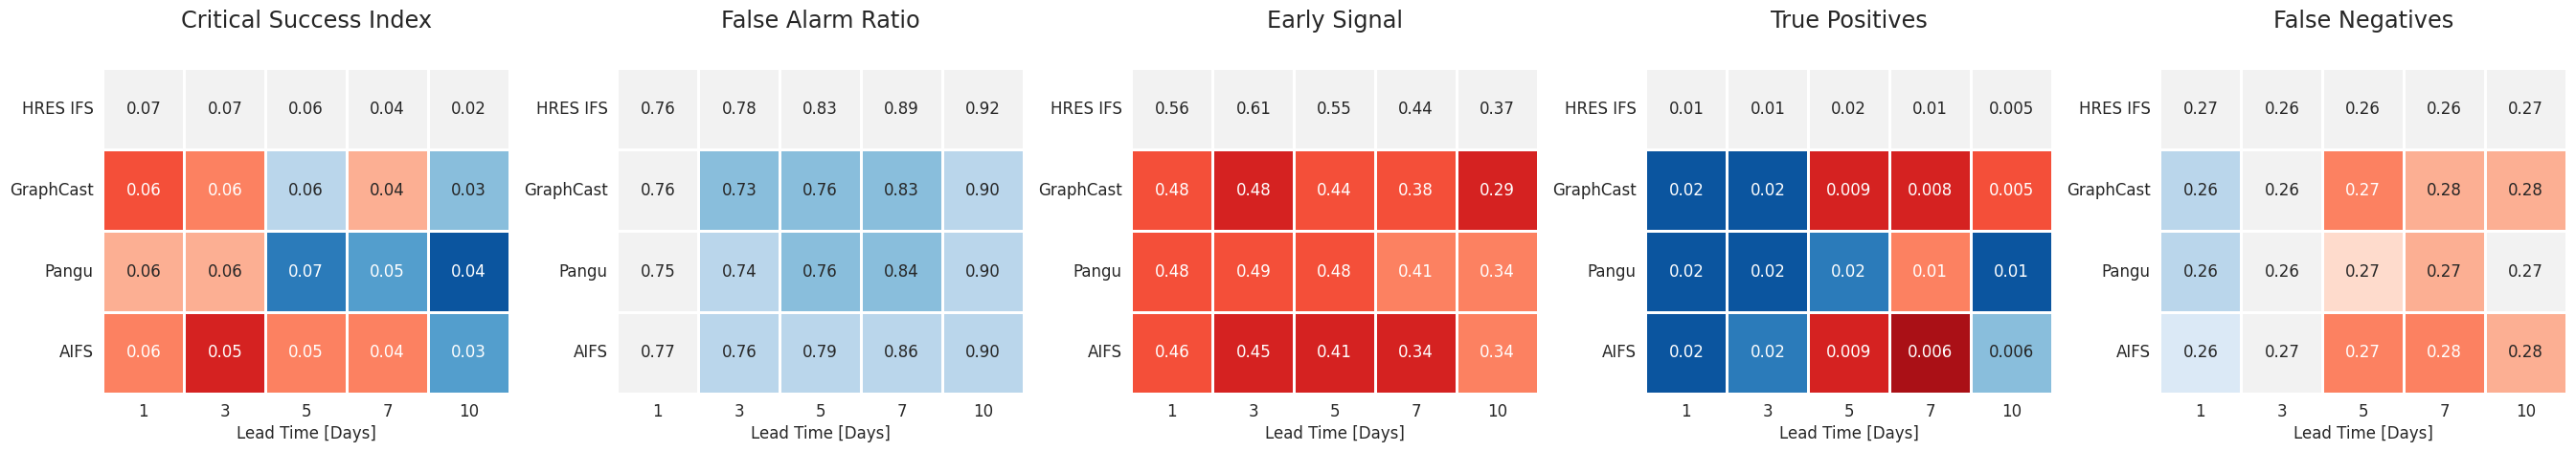

In [12]:
# quick plot of the non-event results in heatmap format
marginal_settings = {}
marginal_settings["subplot_titles"] = severe_display_str
marginal_settings["metric_str"] = severe_metric_str
marginal_settings["lead_time_days"] = lead_time_days
marginal_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]


plot_utils.plot_heatmap(
    na_marginal_rel_error,
    na_marginal_error,
    marginal_settings,
)



(32, 30)
plotting the cases for each event type
combined_event_type: severe_convection
combined_event_type: severe_convection
combined_event_type: marginal_severe_convection


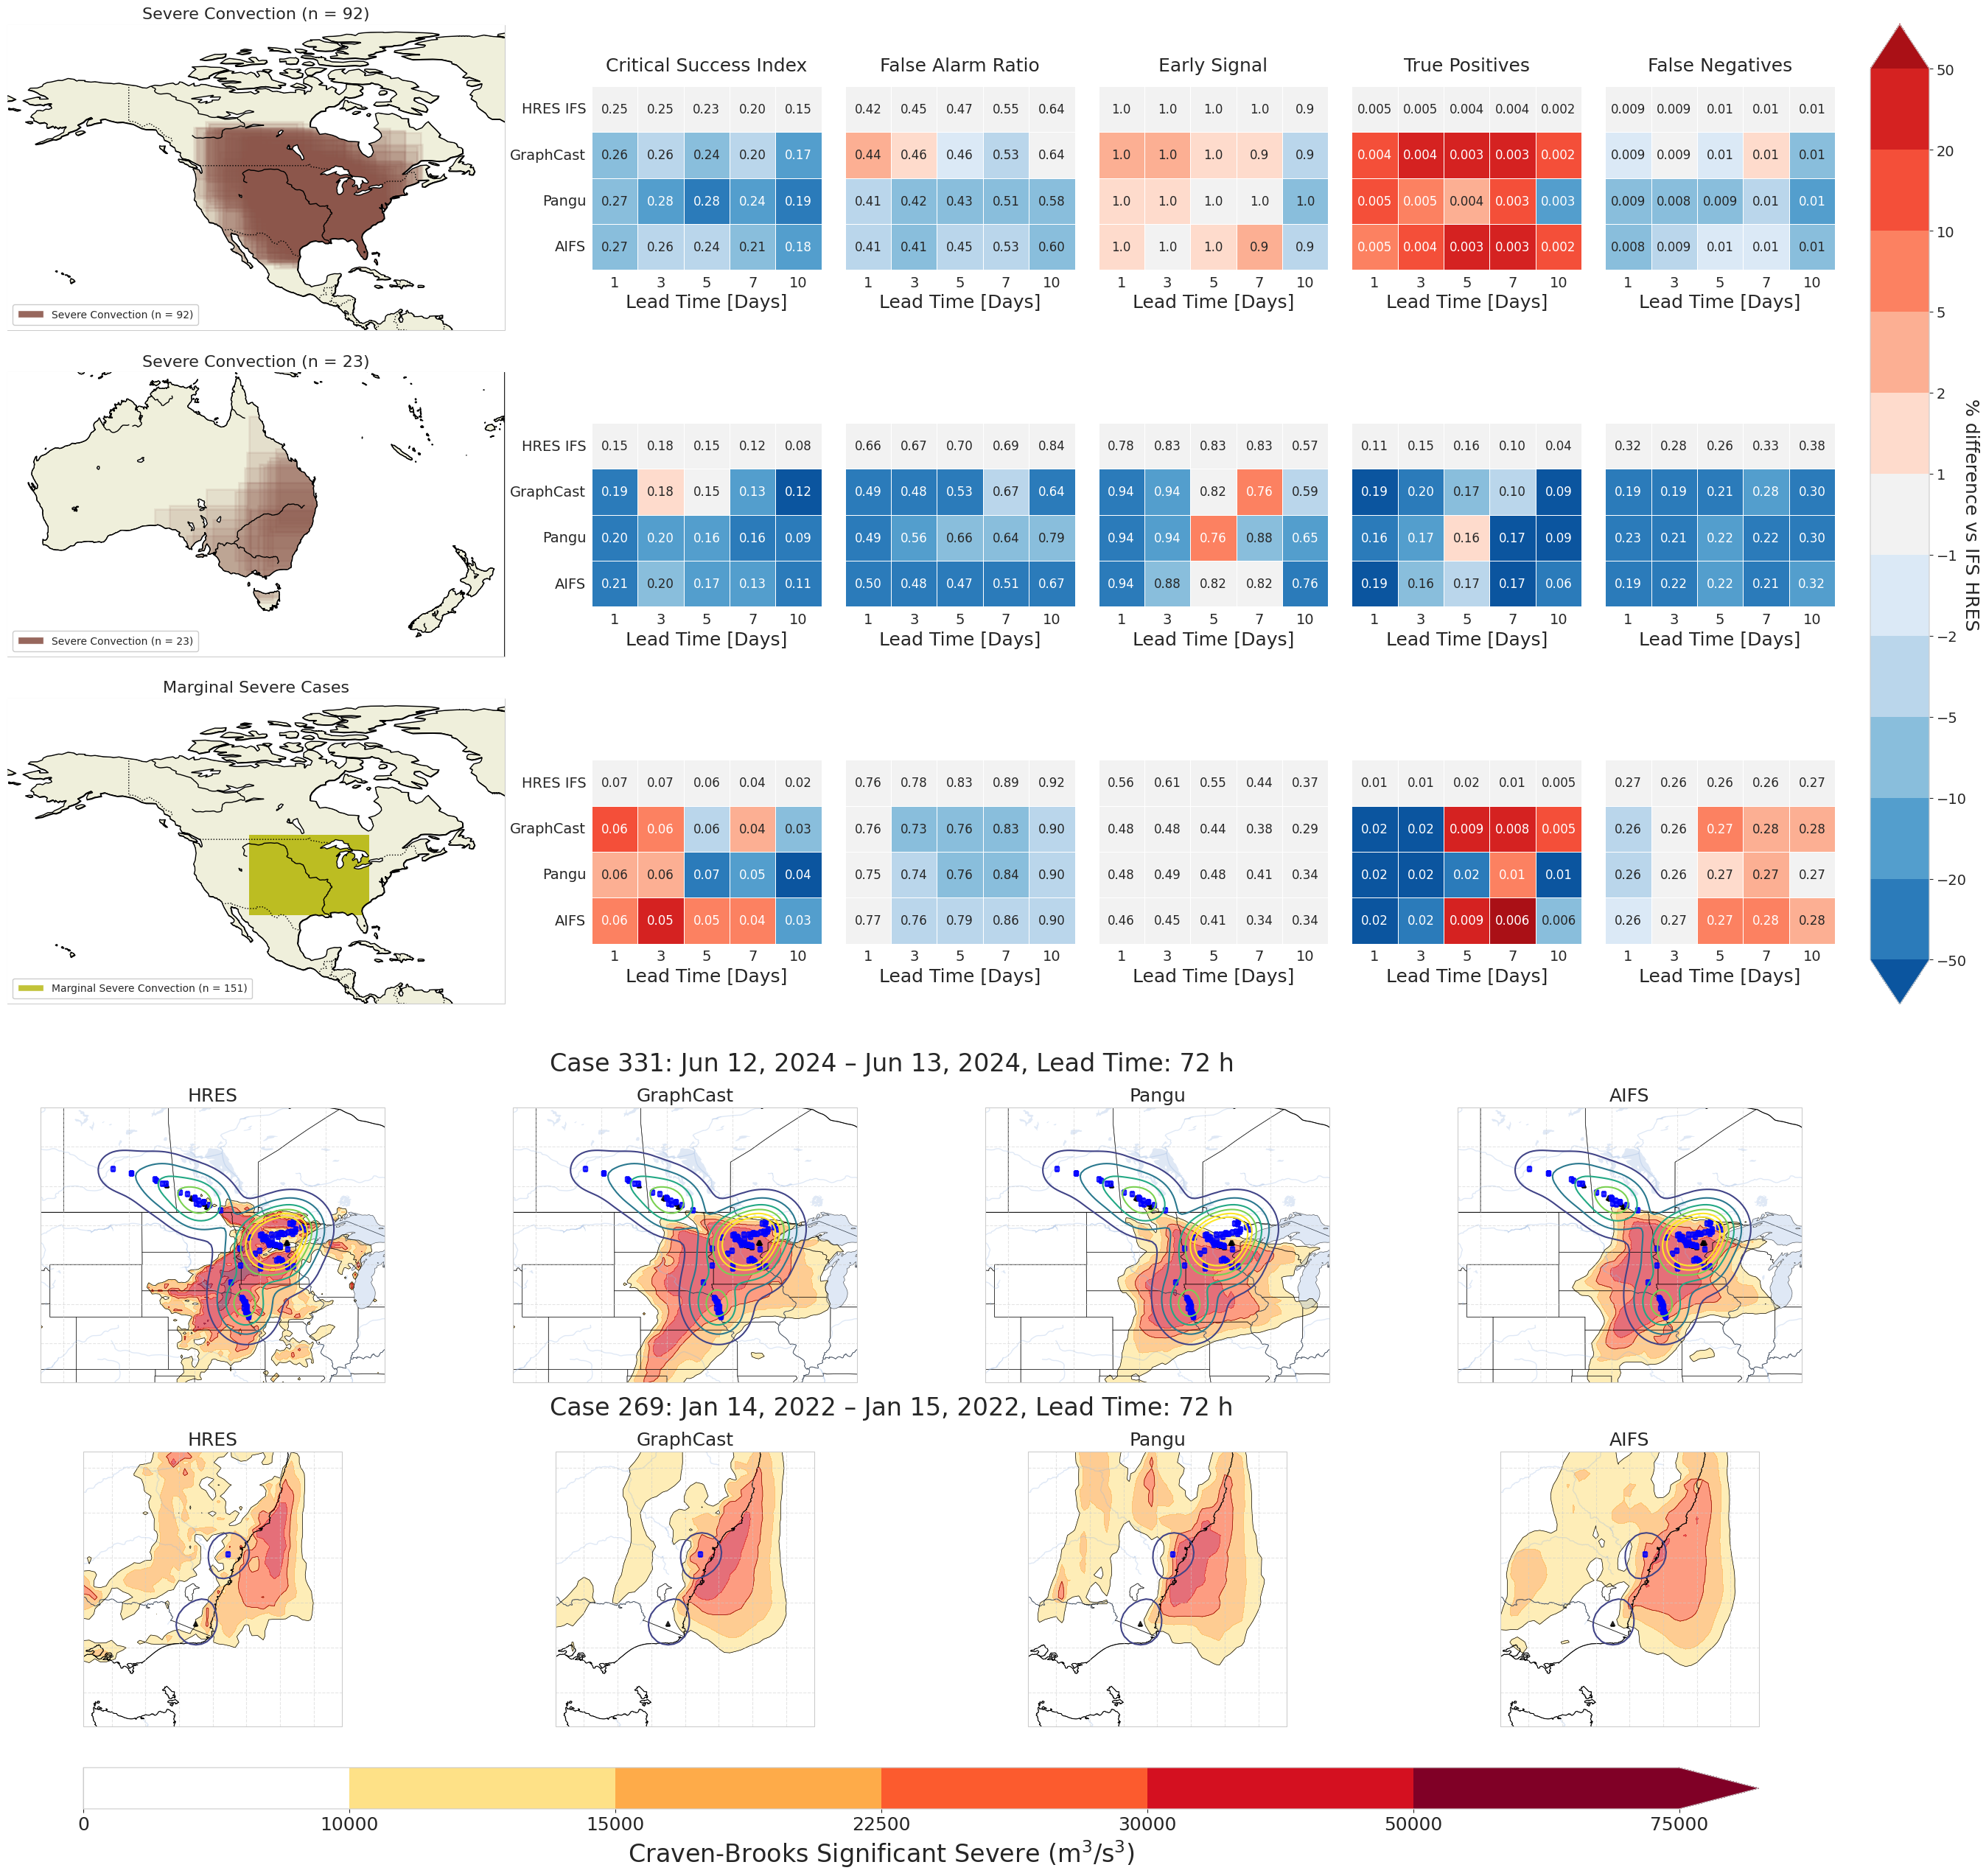

In [15]:
n_rows = 5
n_cols_top = 2  # Columns for top 3 rows
n_cols_bottom = 4  # Columns for bottom 2 rows (more Cartopy plots)
figsize = (8 * max(n_cols_top, n_cols_bottom), 6 * n_rows)
print(figsize)

# Create figure first
fig = plt.figure(figsize=figsize)

# Main GridSpec: 5 rows, use max columns for layout
# Top 3 rows will use 2 columns, bottom 2 rows will use 4 columns
gs_main = GridSpec(n_rows, 1, figure=fig, 
                #    left=0.05, right=0.95, top=0.98, bottom=0.02,
                   hspace=0.4)

# Create subplots for top 3 rows (2 columns each)
gs_top = GridSpecFromSubplotSpec(3, n_cols_top, subplot_spec=gs_main[0:3, 0],
                                  wspace=0.1, hspace=0.1,
                                  width_ratios=[1, 2.5])

# Create subplots for bottom 2 rows (4 columns each - all Cartopy)
gs_bottom = GridSpecFromSubplotSpec(2, n_cols_bottom, subplot_spec=gs_main[3:5, 0],
                                     wspace=0.15, hspace=0.25)

# Create all subplots - initialize as array with shape (n_rows, max_cols)
max_cols = max(n_cols_top, n_cols_bottom)
axs = np.empty((n_rows, max_cols), dtype=object)

# Top 3 rows: 2 columns (Cartopy on left, regular on right)
for i in range(3):
    # Left column: Cartopy
    ax_cartopy = fig.add_subplot(gs_top[i, 0], projection=ccrs.PlateCarree())
    axs[i,0] = ax_cartopy

    # Right column: Regular matplotlib
    ax_regular = fig.add_subplot(gs_top[i, 1])
    axs[i,1] = ax_regular

# Bottom 2 rows: 4 columns (all Cartopy)
for i in range(2):
    for j in range(n_cols_bottom):
        ax_cartopy = fig.add_subplot(gs_bottom[i, j], projection=ccrs.PlateCarree())
        axs[i+3,j] = ax_cartopy


# the left hand column of figure one shows all of the cases for each event type
# plot the cases for each event type
print("plotting the cases for each event type")
_figure3_case_map_gridlines = dict(
    show_left_labels=False,
    show_bottom_labels=False,
    show_top_labels=False,
    show_right_labels=False,
)
# plot_utils.plot_all_cases_and_obs(
#     ewb_cases,
#     event_type="severe_convection",
#     targets=case_operators_with_targets_established,
#     ax=axs[0, 0],
#     map_gridlines=_figure3_case_map_gridlines,
# )


# plot the cases for north america
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="severe_convection",
    bounding_box=na_bounding_box,
    ax=axs[0, 0],
    fill_boxes=True,
)

# plot the cases for australia
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="severe_convection",
    bounding_box=au_bounding_box,
    ax=axs[1, 0],
    fill_boxes=True,
)

plot_utils.plot_all_cases(
    marginal_severe_cases,
    event_type="severe_convection",
    bounding_box=na_bounding_box,
    ax=axs[2, 0],
    title="Marginal Severe Cases",
    is_marginal=True,
    fill_boxes=True,
)

# Strip lon/lat labels from any GridLiners (e.g. duplicates or other sources)
for _i in range(3):
    _ax = axs[_i, 0]
    for _artist in getattr(_ax, "artists", []):
        if hasattr(_artist, "bottom_labels"):
            _artist.left_labels = False
            _artist.right_labels = False
            _artist.top_labels = False
            _artist.bottom_labels = False


severe_settings = {}
severe_settings["subplot_titles"] = severe_display_str
severe_settings["metric_str"] = severe_metric_str
severe_settings["lead_time_days"] = lead_time_days
severe_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

# second column of figure 2 shows the scorecard
# scorecard_mappable = plot_utils.plot_heatmap(
#     global_rel_severe_error,
#     global_severe_error,
#     severe_settings,
#     ax=axs[0, 1],
#     return_mappable=True,
# )

scorecard_mappable = plot_utils.plot_heatmap(
    na_rel_severe_error,
    na_severe_error,
    severe_settings,
    ax=axs[0, 1],
    return_mappable=True,
)

plot_utils.plot_heatmap(
    au_rel_severe_error,
    au_severe_error,
    severe_settings,
    ax=axs[1, 1],
    show_titles=False,
)

plot_utils.plot_heatmap(
    na_marginal_rel_error,
    na_marginal_error,
    severe_settings,
    ax=axs[2, 1],
    show_titles=False,
    show_coloring = [True, True, False, True, True]
)

# plot the colorbar to the right of the heatmaps
plot_utils.add_scorecard_colorbar_right(
    fig,
    scorecard_mappable,
    [axs[i, 1] for i in range(3)],
    n_subplots=3,
)

# in the 4th row, plot the cbss and pph for all the models
my_id = 331
my_case = [c for c in ewb_cases if c.case_id_number == my_id][0]
my_lsr = get_lsr_from_case_op(my_case, case_operators_with_targets_established)

cbss_hres, pph_hres = hres_graphics[my_id, "cbss"], hres_graphics[my_id, "pph"]
cbss_gc, pph_gc = gc_graphics[my_id, "cbss"], gc_graphics[my_id, "pph"]
cbss_pang, pph_pang = pang_graphics[my_id, "cbss"], pang_graphics[my_id, "pph"]
cbss_aifs, pph_aifs = aifs_graphics[my_id, "cbss"], aifs_graphics[my_id, "pph"]

# Label above row 3 panels
lead_time_hours = 72
_pos = axs[3, 0].get_position()
fig.text(
    0.5, _pos.y1 + 0.03,
    f"Case {my_id}: {my_case.start_date.strftime('%b %d, %Y')} – "
    f"{my_case.end_date.strftime('%b %d, %Y')}, Lead Time: {lead_time_hours} h",
    size=24, ha='center', va='bottom',
)
plot_cbss_pph_panel(cbss_hres, pph_hres, my_case, lsrs=my_lsr, ax=axs[3, 0], 
    title="HRES", lead_time_hours=lead_time_hours, 
    gridlines_kwargs={"show_left_labels": False, "show_bottom_labels": False})
plot_cbss_pph_panel(cbss_gc, pph_gc, my_case, lsrs=my_lsr, ax=axs[3, 1], 
    title="GraphCast", lead_time_hours=lead_time_hours, 
    gridlines_kwargs={"show_left_labels": False, "show_bottom_labels": False})
plot_cbss_pph_panel(cbss_pang, pph_pang, my_case, lsrs=my_lsr, ax=axs[3, 2], 
    title="Pangu", lead_time_hours=lead_time_hours, 
    gridlines_kwargs={"show_left_labels": False, "show_bottom_labels": False})
plot_cbss_pph_panel(cbss_aifs, pph_aifs, my_case, lsrs=my_lsr, ax=axs[3, 3], 
    title="AIFS", lead_time_hours=lead_time_hours, 
    gridlines_kwargs={"show_left_labels": False, "show_bottom_labels": False})

# # the bottom row will be australia but we are plotting NA until AUS works
# # in the 4th row, plot the cbss and pph for all the models
my_id = 269
my_case = [c for c in ewb_cases if c.case_id_number == my_id][0]
my_lsr = get_lsr_from_case_op(my_case, case_operators_with_targets_established)

cbss_hres, pph_hres = hres_graphics[my_id, "cbss"], hres_graphics[my_id, "pph"]
cbss_gc, pph_gc = gc_graphics[my_id, "cbss"], gc_graphics[my_id, "pph"]
cbss_pang, pph_pang = pang_graphics[my_id, "cbss"], pang_graphics[my_id, "pph"]
cbss_aifs, pph_aifs = aifs_graphics[my_id, "cbss"], aifs_graphics[my_id, "pph"]

# Label above row 4 panels
_pos = axs[4, 0].get_position()
fig.text(
    0.5, _pos.y1 + 0.03,
    f"Case {my_id}: {my_case.start_date.strftime('%b %d, %Y')} – "
    f"{my_case.end_date.strftime('%b %d, %Y')}, Lead Time: {lead_time_hours} h",
    size=24, ha='center', va='bottom',
)
plot_cbss_pph_panel(cbss_hres, pph_hres, my_case, lsrs=my_lsr, ax=axs[4, 0], 
    title="HRES", lead_time_hours=lead_time_hours, 
    gridlines_kwargs={"show_left_labels": False, "show_bottom_labels": False})
plot_cbss_pph_panel(cbss_gc, pph_gc, my_case, lsrs=my_lsr, ax=axs[4, 1], 
    title="GraphCast", lead_time_hours=lead_time_hours, 
    gridlines_kwargs={"show_left_labels": False, "show_bottom_labels": False})
plot_cbss_pph_panel(cbss_pang, pph_pang, my_case, lsrs=my_lsr, ax=axs[4, 2], 
    title="Pangu", lead_time_hours=lead_time_hours, 
    gridlines_kwargs={"show_left_labels": False, "show_bottom_labels": False})
plot_cbss_pph_panel(cbss_aifs, pph_aifs, my_case, lsrs=my_lsr, ax=axs[4, 3], 
    title="AIFS", lead_time_hours=lead_time_hours, 
    gridlines_kwargs={"show_left_labels": False, "show_bottom_labels": False})

# plot the colorbar at the bottom of the figure (CBSS)
cmap, norm, levels = severe_utils.setup_cbss_colormap_and_levels()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plot_utils.add_horizontal_colorbar_below(
    fig,
    sm,
    [axs[4, j] for j in range(4)],
    n_subplots=4,
    levels=levels,
    extend="max",
    label=r"Craven-Brooks Significant Severe (m$^{3}$/s$^{3}$)",
    label_fontsize=24,
    tick_labelsize=18,
)

plt.savefig(basepath + "graphics/paper/figure3.png", dpi=300, bbox_inches="tight")

# Methods graphics

(24, 12)


(<GeoAxes: title={'center': 'Case 8001: Sep 02, 2022 – Sep 03, 2022'}>,
 <cartopy.mpl.contour.GeoContourSet at 0x7f5af3e59310>)

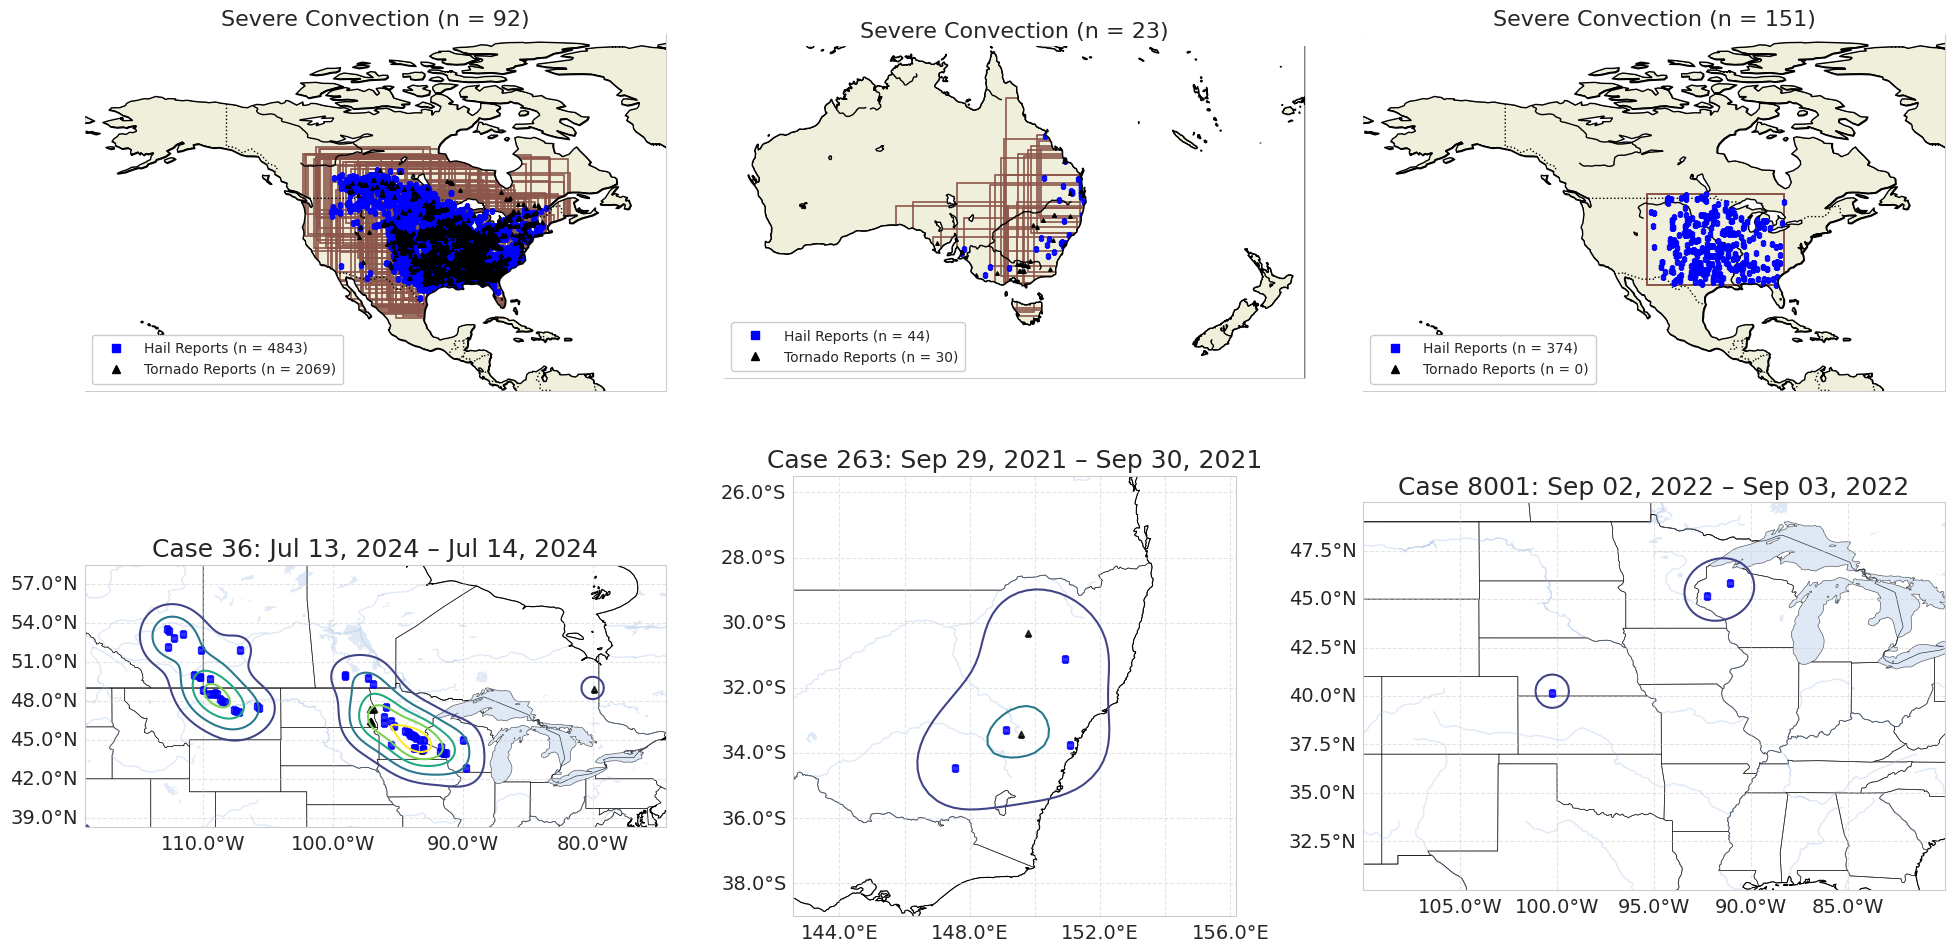

In [16]:
# for the methods sections, we want to plot all the observations for each area and then a case study with PPH 
# for each area

n_rows = 2
n_cols = 3  # Columns for top 3 rows
figsize = (8 * n_cols, 6 * n_rows)
print(figsize)

# Create figure first
fig = plt.figure(figsize=figsize)

gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.1, wspace=0.1)
axs = np.empty((n_rows, n_cols), dtype=object)

# set it up so they are all cartopy plots
for i in range(n_rows):
    for j in range(n_cols):
        ax_cartopy = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
        axs[i, j] = ax_cartopy

# now plot the observations in the top row
plot_utils.plot_all_cases_and_obs(
    ewb_cases,
    event_type="severe_convection",
    targets=case_operators_with_targets_established,
    bounding_box=na_bounding_box,
    ax=axs[0, 0],
)

plot_utils.plot_all_cases_and_obs(
    ewb_cases,
    event_type="severe_convection",
    targets=case_operators_with_targets_established,
    bounding_box=au_bounding_box,
    ax=axs[0, 1],
)

plot_utils.plot_all_cases_and_obs(
    marginal_severe_cases,
    event_type="severe_convection",
    targets=marginal_severe_case_operators_with_targets_established,
    bounding_box=na_bounding_box,
    ax=axs[0, 2],
)

# on the bottom row, show an example PPH and observation for each model
def _case_title(case):
    return (
        f"Case {case.case_id_number}: "
        f"{case.start_date.strftime('%b %d, %Y')} \u2013 "
        f"{case.end_date.strftime('%b %d, %Y')}"
    )

my_id = 36
my_case = [c for c in ewb_cases if c.case_id_number == my_id][0]
my_lsr = get_lsr_from_case_op(my_case, case_operators_with_targets_established)
my_pph = get_pph_outputs(my_case, case_operators_with_targets_established)

plot_pph_panel(my_pph, my_case, my_lsr, ax=axs[1, 0], title=_case_title(my_case))

# plot the PPH for an example in australia
my_id = 263
my_case = [c for c in ewb_cases if c.case_id_number == my_id][0]
my_lsr = get_lsr_from_case_op(my_case, case_operators_with_targets_established)
my_pph = get_pph_outputs(my_case, case_operators_with_targets_established)

plot_pph_panel(my_pph, my_case, my_lsr, ax=axs[1, 1], title=_case_title(my_case))

# and plot a marginal case
my_id = 8001
my_case = [c for c in marginal_severe_cases if c.case_id_number == my_id][0]
my_lsr = get_lsr_from_case_op(my_case, marginal_severe_case_operators_with_targets_established)
my_pph = get_pph_outputs(my_case, marginal_severe_case_operators_with_targets_established)

plot_pph_panel(my_pph, my_case, my_lsr, ax=axs[1, 2], title=_case_title(my_case))



# talk graphics below (same as above without the subplots)

plotting the cases for each event type
combined_event_type: severe_convection
combined_event_type: severe_convection
combined_event_type: marginal_severe_convection


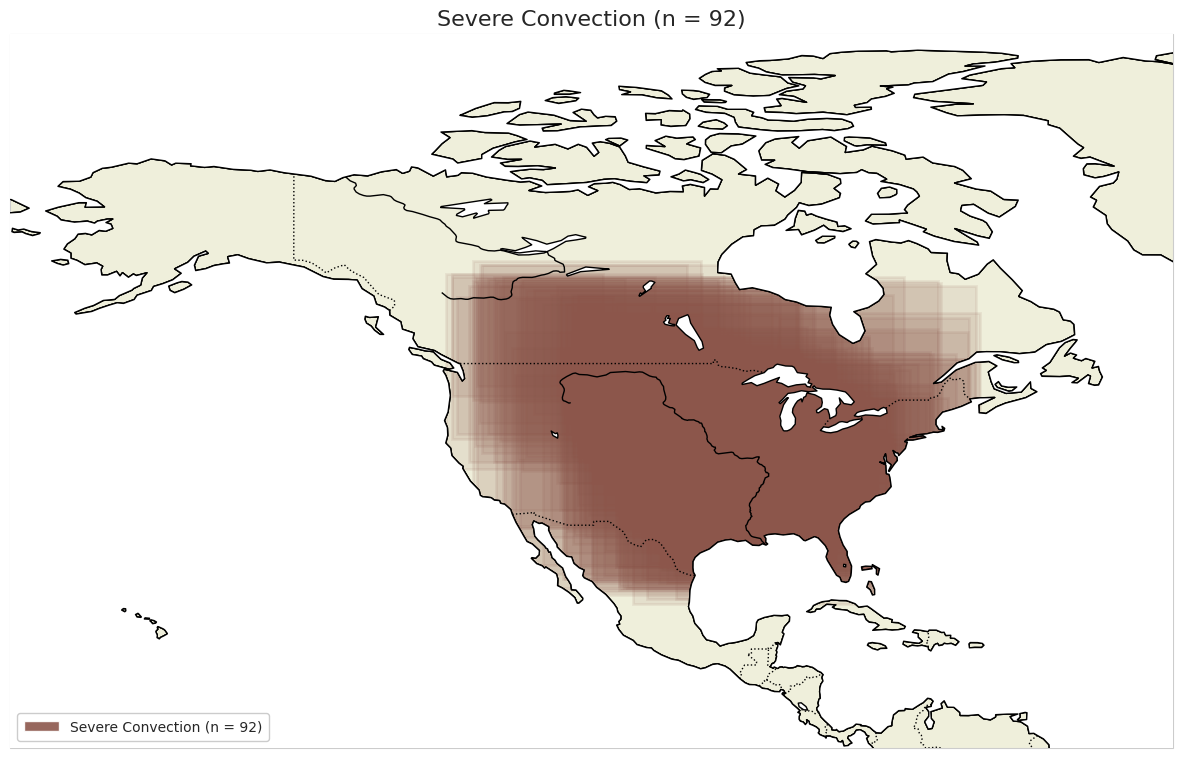

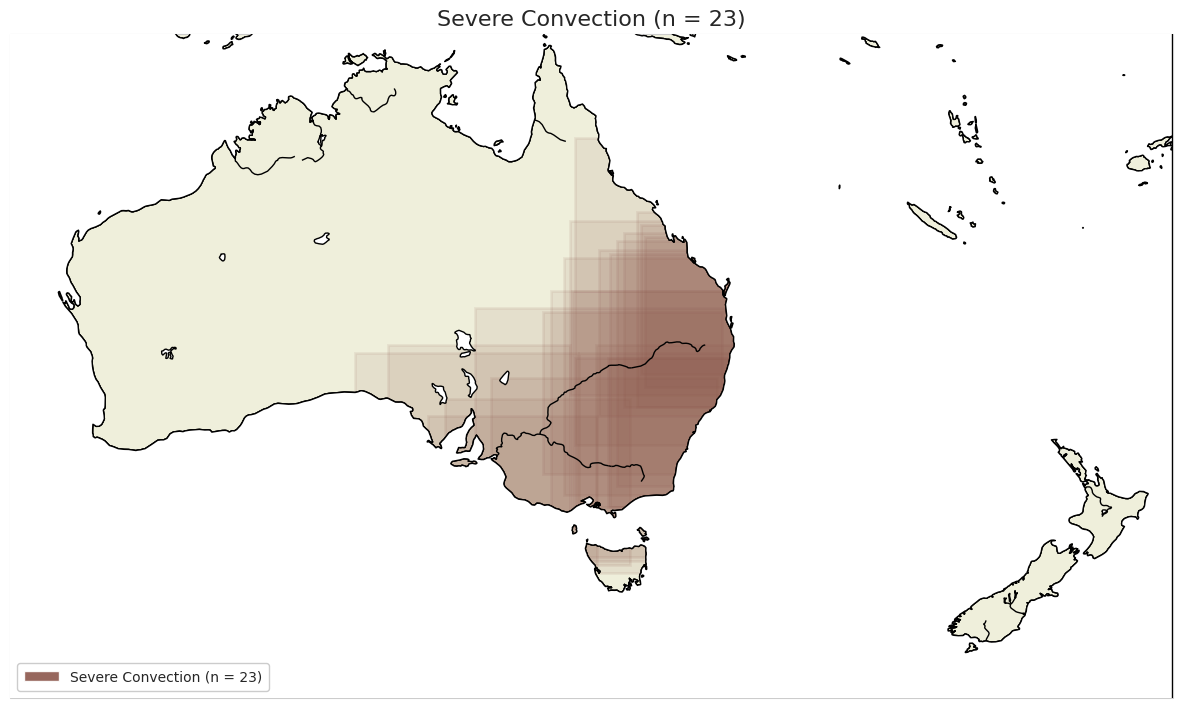

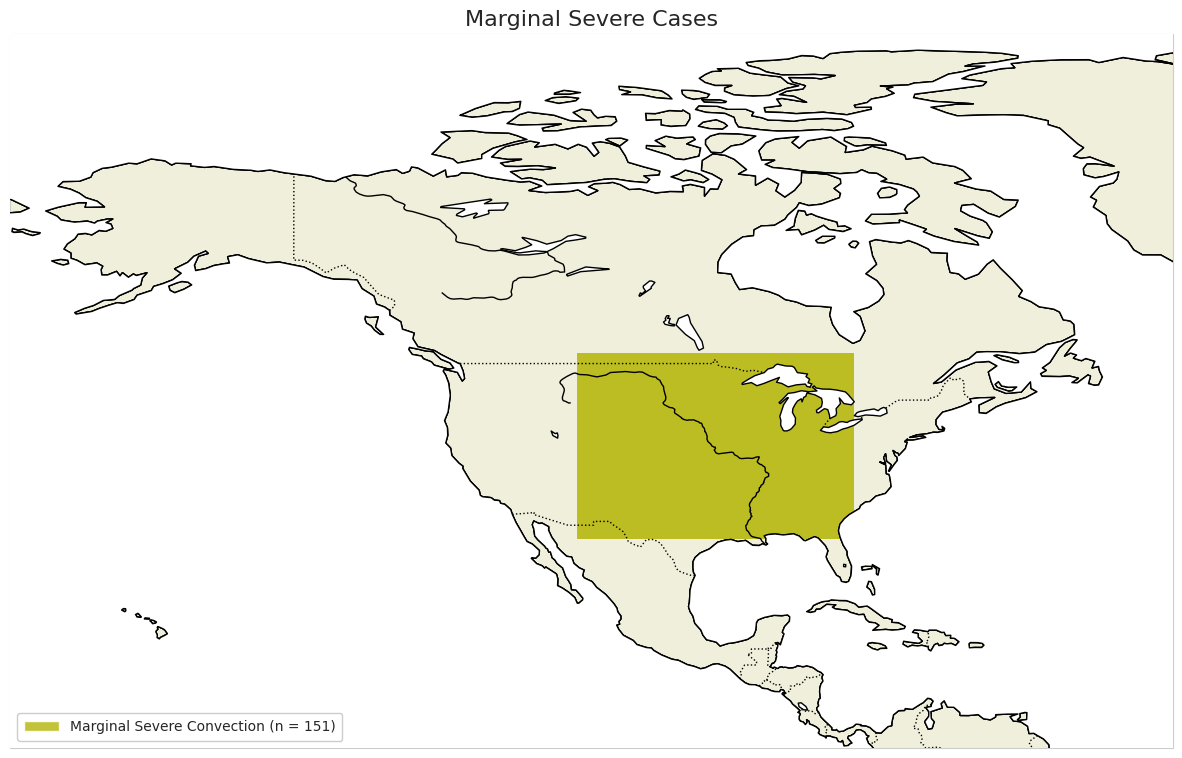

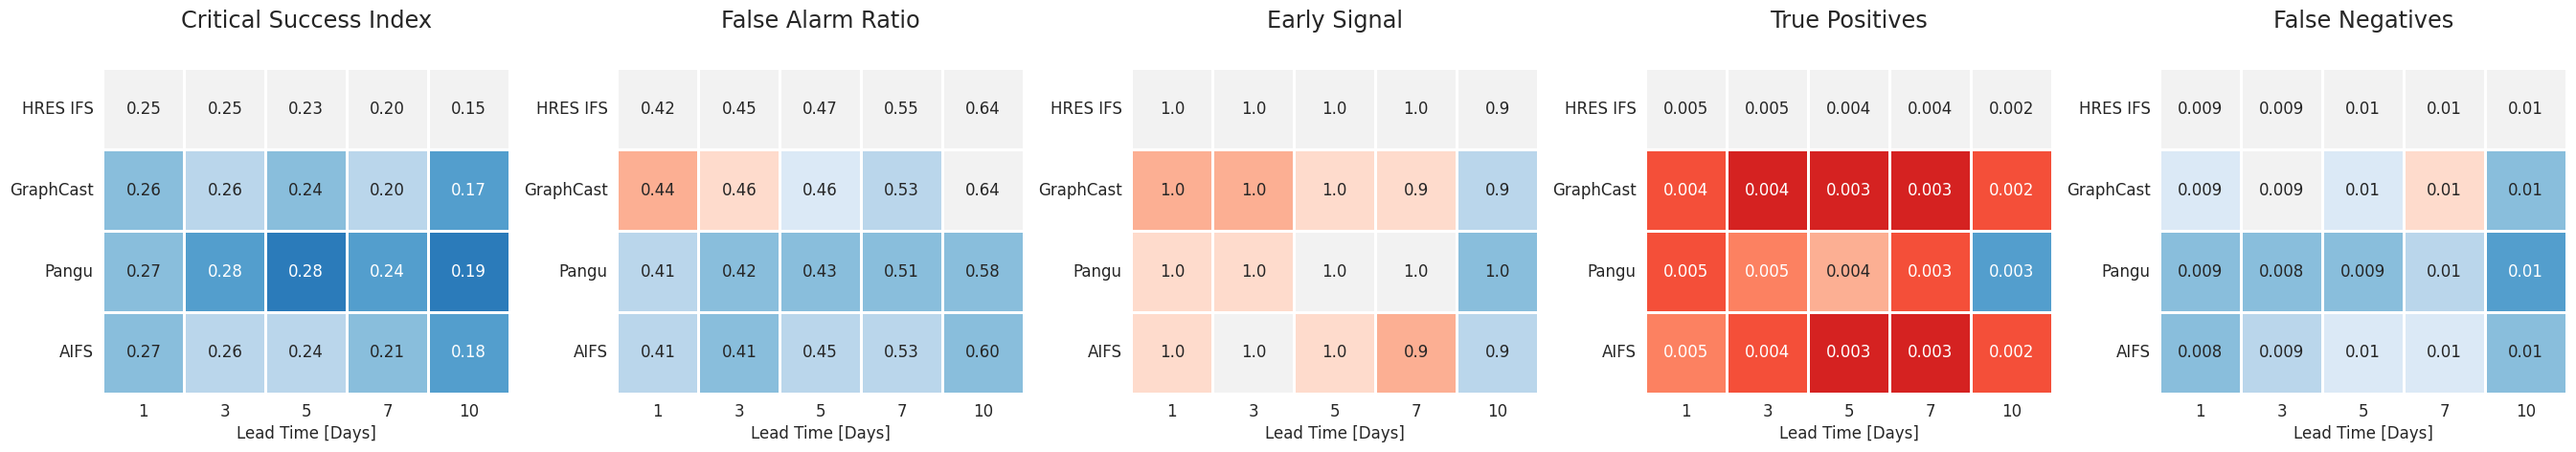

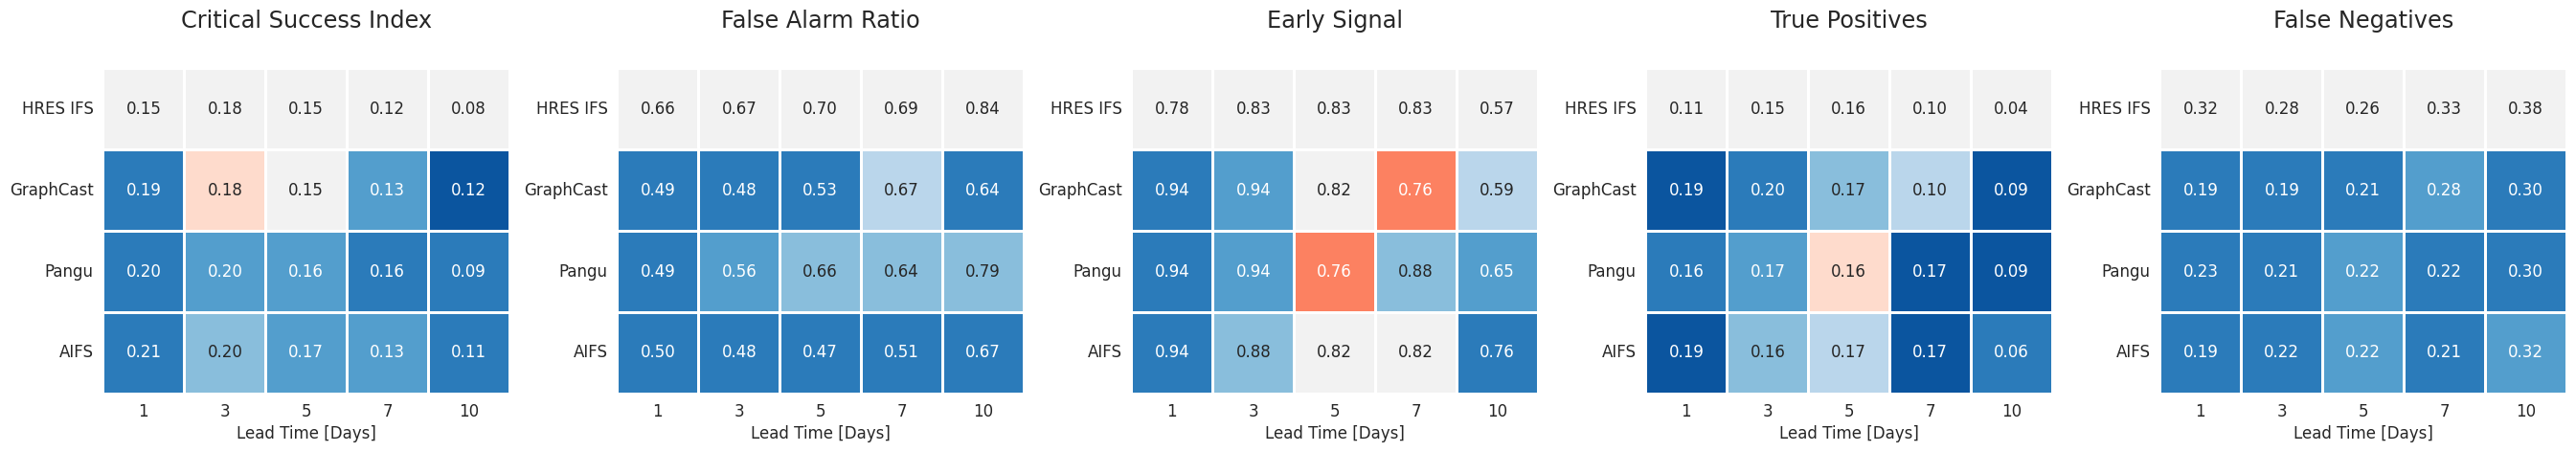

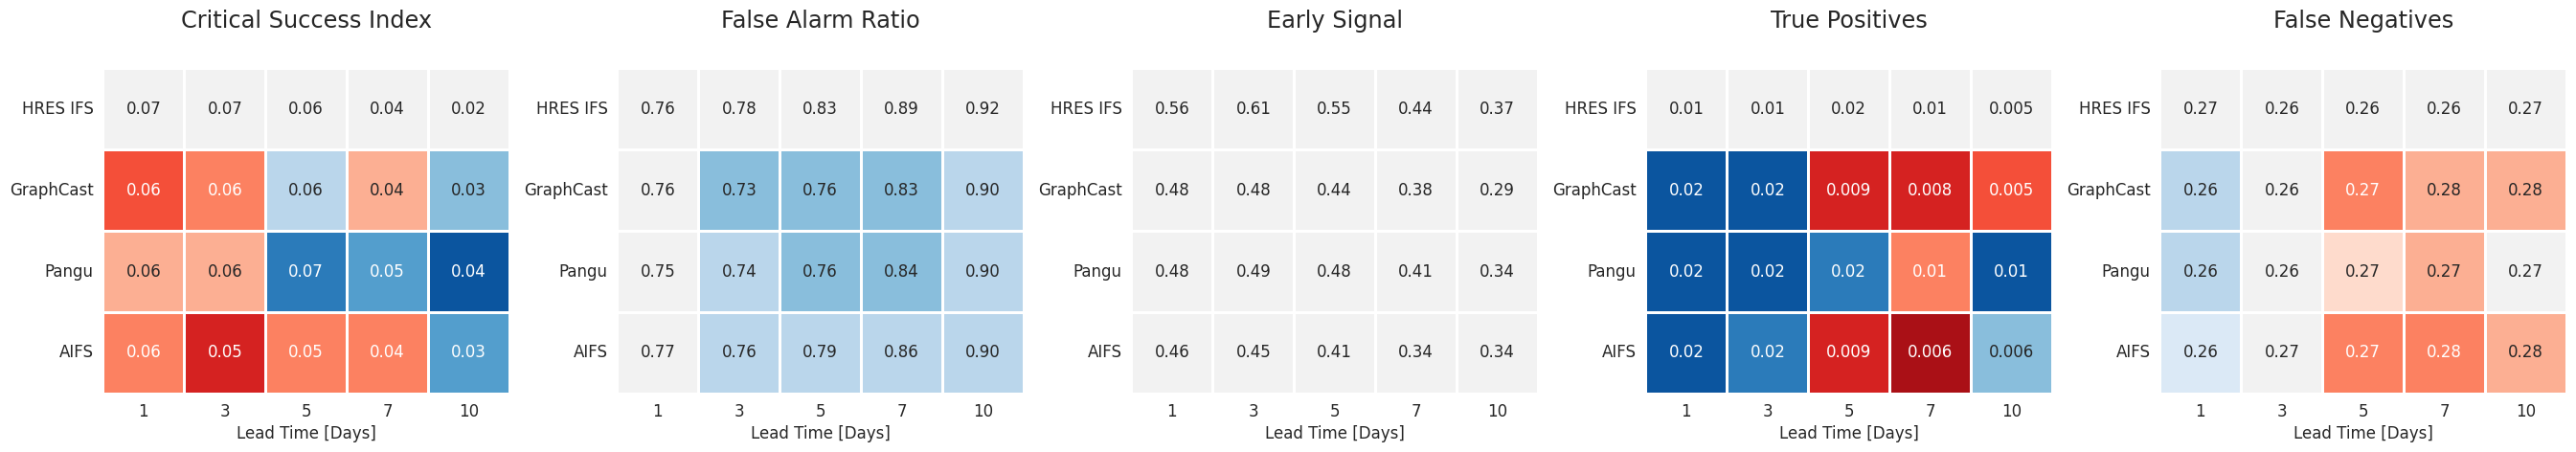

In [17]:
print("plotting the cases for each event type")
_figure3_case_map_gridlines = dict(
    show_left_labels=False,
    show_bottom_labels=False,
    show_top_labels=False,
    show_right_labels=False,
)

# plot the cases for north america
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="severe_convection",
    bounding_box=na_bounding_box,
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/figure3_severe_na.png", dpi=300)

# plot the cases for australia
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="severe_convection",
    bounding_box=au_bounding_box,
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/figure3_severe_au.png", dpi=300)

plot_utils.plot_all_cases(
    marginal_severe_cases,
    event_type="severe_convection",
    bounding_box=na_bounding_box,
    title="Marginal Severe Cases",
    is_marginal=True,
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/figure3_severe_marginal.png", dpi=300)

severe_settings = {}
severe_settings["subplot_titles"] = severe_display_str
severe_settings["metric_str"] = severe_metric_str
severe_settings["lead_time_days"] = lead_time_days
severe_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

plot_utils.plot_heatmap(
    na_rel_severe_error,
    na_severe_error,
    severe_settings,
    show_titles=True,
    show_xlabel=True,
)
plt.savefig(basepath + "graphics/paper/figure3_severe_scorecard_na.png", dpi=300)

plot_utils.plot_heatmap(
    au_rel_severe_error,
    au_severe_error,
    severe_settings,
    show_titles=True,
    show_xlabel=True,
)
plt.savefig(basepath + "graphics/paper/figure3_severe_scorecard_au.png", dpi=300)

plot_utils.plot_heatmap(
    na_marginal_rel_error,
    na_marginal_error,
    severe_settings,
    show_titles=True,
    show_xlabel=True,
    show_coloring = [True, True, False, True, True]
)
plt.savefig(basepath + "graphics/paper/figure3_severe_scorecard_marginal.png", dpi=300)


# method graphics sub panels

In [ ]:
# now plot the observations in the top row
plot_utils.plot_all_cases_and_obs(
    ewb_cases,
    event_type="severe_convection",
    targets=case_operators_with_targets_established,
    bounding_box=na_bounding_box,
)
plt.savefig(basepath + "graphics/paper/figure3_severe_methods_obs_na.png", dpi=300)

plot_utils.plot_all_cases_and_obs(
    ewb_cases,
    event_type="severe_convection",
    targets=case_operators_with_targets_established,
    bounding_box=au_bounding_box,
)
plt.savefig(basepath + "graphics/paper/figure3_severe_methods_obs_au.png", dpi=300)
plot_utils.plot_all_cases_and_obs(
    marginal_severe_cases,
    event_type="severe_convection",
    targets=marginal_severe_case_operators_with_targets_established,
    bounding_box=na_bounding_box,
)
plt.savefig(basepath + "graphics/paper/figure3_severe_methods_obs_marginal.png", dpi=300)

# on the bottom row, show an example PPH and observation for each model
def _case_title(case):
    return (
        f"Case {case.case_id_number}: "
        f"{case.start_date.strftime('%b %d, %Y')} \u2013 "
        f"{case.end_date.strftime('%b %d, %Y')}"
    )

my_id = 36
my_case = [c for c in ewb_cases if c.case_id_number == my_id][0]
my_lsr = get_lsr_from_case_op(my_case, case_operators_with_targets_established)
my_pph = get_pph_outputs(my_case, case_operators_with_targets_established)

plot_pph_panel(my_pph, my_case, my_lsr, title=_case_title(my_case))
plt.savefig(basepath + "graphics/paper/figure3_severe_methods_pph_na.png", dpi=300)

# plot the PPH for an example in australia
my_id = 263
my_case = [c for c in ewb_cases if c.case_id_number == my_id][0]
my_lsr = get_lsr_from_case_op(my_case, case_operators_with_targets_established)
my_pph = get_pph_outputs(my_case, case_operators_with_targets_established)

plot_pph_panel(my_pph, my_case, my_lsr, title=_case_title(my_case))
plt.savefig(basepath + "graphics/paper/figure3_severe_methods_pph_au.png", dpi=300)

# and plot a marginal case
my_id = 8001
my_case = [c for c in marginal_severe_cases if c.case_id_number == my_id][0]
my_lsr = get_lsr_from_case_op(my_case, marginal_severe_case_operators_with_targets_established)
my_pph = get_pph_outputs(my_case, marginal_severe_case_operators_with_targets_established)

plot_pph_panel(my_pph, my_case, my_lsr, title=_case_title(my_case))
plt.savefig(basepath + "graphics/paper/figure3_severe_methods_pph_marginal.png", dpi=300)